In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("Data.csv")

In [3]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2965 entries, 0 to 2964
Data columns (total 10 columns):
 #   Column                                                                        Non-Null Count  Dtype  
---  ------                                                                        --------------  -----  
 0   Country Name                                                                  2965 non-null   object 
 1   Time                                                                          2965 non-null   int64  
 2   Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS]                     2965 non-null   float64
 3   Imports of goods and services (% of GDP) [NE.IMP.GNFS.ZS]                     2965 non-null   float64
 4   GDP (current US$) [NY.GDP.MKTP.CD]                                            2965 non-null   float64
 5   Population, total [SP.POP.TOTL]                                               2965 non-null   int64  
 6   Foreign direct investment, net i

In [4]:
columns_to_drop = ["Country Name", "Time"]
df.drop(columns=columns_to_drop, inplace=True)

In [5]:
df = df.replace("..", pd.NA)

print(f"Shape before dropping any nulls: {df.shape}")
df.dropna(inplace=True)

print(f"Shape after dropping all nulls:  {df.shape}")

Shape before dropping any nulls: (2965, 8)
Shape after dropping all nulls:  (2961, 8)


In [6]:
df = df.rename(columns={
    'Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS]': 'Exports_%_GDP',
    'Imports of goods and services (% of GDP) [NE.IMP.GNFS.ZS]': 'Imports_%_GDP',
    'GDP (current US$) [NY.GDP.MKTP.CD]': 'GDP_USD',
    'Population, total [SP.POP.TOTL]': 'Population',
    'Foreign direct investment, net inflows (% of GDP) [BX.KLT.DINV.WD.GD.ZS]': 'FDI_%_GDP',
    'General government final consumption expenditure (% of GDP) [NE.CON.GOVT.ZS]': 'Govt_Exp_%_GDP',
    'Oil rents (% of GDP) [NY.GDP.PETR.RT.ZS]': 'Oil_Rents_%_GDP',
    'Official exchange rate (LCU per US$, period average) [PA.NUS.FCRF]': 'Exchange_Rate'
})


In [7]:
for col in ['FDI_%_GDP', 'Oil_Rents_%_GDP', 'Exchange_Rate']:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [8]:
df['Exports_USD'] = (df['Exports_%_GDP'] / 100) * df['GDP_USD']
df['Imports_USD'] = (df['Imports_%_GDP'] / 100) * df['GDP_USD']
df['FDI_USD'] = (df['FDI_%_GDP'] / 100) * df['GDP_USD']
df['Govt_Exp_USD'] = (df['Govt_Exp_%_GDP'] / 100) * df['GDP_USD']
df['Oil_Rents_USD'] = (df['Oil_Rents_%_GDP'] / 100) * df['GDP_USD']


In [9]:
df = df.drop(columns=['Exports_%_GDP', 'Imports_%_GDP', 'FDI_%_GDP', 'Govt_Exp_%_GDP', 'Oil_Rents_%_GDP'])


In [10]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 2961 entries, 0 to 2964
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   GDP_USD        2961 non-null   float64
 1   Population     2961 non-null   int64  
 2   Exchange_Rate  2961 non-null   float64
 3   Exports_USD    2961 non-null   float64
 4   Imports_USD    2961 non-null   float64
 5   FDI_USD        2961 non-null   float64
 6   Govt_Exp_USD   2961 non-null   float64
 7   Oil_Rents_USD  2961 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 208.2 KB


,GDP_USD,Population,Exchange_Rate,Exports_USD,Imports_USD,FDI_USD,Govt_Exp_USD,Oil_Rents_USD
0,2.905093e+09,3187784,92.697500,3.564448e+08,8.096217e+08,7.000000e+07,2.909316e+08,3.368502e+07
1,3.234486e+09,3168033,104.498917,3.718089e+08,1.064684e+09,9.010000e+07,3.104914e+08,3.754277e+07
2,2.293666e+09,3148281,148.932917,2.303035e+08,7.956390e+08,4.750000e+07,2.421312e+08,2.496326e+07
3,2.600357e+09,3128530,150.633333,2.919500e+08,9.336146e+08,4.501000e+07,2.836741e+08,6.071694e+06
4,3.283942e+09,3108778,137.690583,5.409779e+08,1.097558e+09,4.120000e+07,3.660730e+08,1.624649e+07


In [11]:
cols_to_convert = ['Exports_USD', 'Imports_USD', 'FDI_USD', 'Govt_Exp_USD', 'Oil_Rents_USD', 'GDP_USD']

df[cols_to_convert] = df[cols_to_convert] / 1e9


In [12]:
X = df[['Exports_USD', 'Imports_USD', 'Population', 'FDI_USD', 'Govt_Exp_USD', 'Oil_Rents_USD', 'Exchange_Rate']]
y = df['GDP_USD']  # GDP now in billions


In [13]:
df[['Exports_USD', 'Imports_USD', 'GDP_USD']].head()


,Exports_USD,Imports_USD,GDP_USD
0,0.356445,0.809622,2.905093
1,0.371809,1.064684,3.234486
2,0.230304,0.795639,2.293666
3,0.291950,0.933615,2.600357
4,0.540978,1.097558,3.283942


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# Predictions
y_pred_rf_test = rf.predict(X_test)
y_pred_gb_test = gb.predict(X_test)
y_pred_rf_train = rf.predict(X_train)
y_pred_gb_train = gb.predict(X_train)

# Evaluation function
def evaluate_model(name, y_true_train, y_pred_train, y_true_test, y_pred_test):
    # Train metrics
    r2_train = r2_score(y_true_train, y_pred_train)
    mae_train = mean_absolute_error(y_true_train, y_pred_train)
    # Test metrics
    r2_test = r2_score(y_true_test, y_pred_test)
    mae_test = mean_absolute_error(y_true_test, y_pred_test)
    mse_test = mean_squared_error(y_true_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)

    print(f"\n{name} Evaluation:")
    print(f"Train R² Score : {r2_train:.4f}")
    print(f"Test  R² Score : {r2_test:.4f}")
    print(f"Train MAE (Billions): {mae_train:.4f}")
    print(f"Test  MAE (Billions): {mae_test:.4f}")
    print(f"Test  MSE (Billions²): {mse_test:.4f}")
    print(f"Test  RMSE (Billions): {rmse_test:.4f}")

# Evaluate both models
evaluate_model("Random Forest", y_train, y_pred_rf_train, y_test, y_pred_rf_test)
evaluate_model("Gradient Boosting", y_train, y_pred_gb_train, y_test, y_pred_gb_test)



Random Forest Evaluation:
Train R² Score : 0.9983
Test  R² Score : 0.9958
Train MAE (Billions): 13.7954
Test  MAE (Billions): 30.7820
Test  MSE (Billions²): 13024.5416
Test  RMSE (Billions): 114.1251

Gradient Boosting Evaluation:
Train R² Score : 0.9994
Test  R² Score : 0.9954
Train MAE (Billions): 23.8672
Test  MAE (Billions): 43.5244
Test  MSE (Billions²): 14150.6459
Test  RMSE (Billions): 118.9565


In [18]:
import pickle
pickle.dump(rf, open("model.pkl", "wb"))


GDP_USD          1.000000
Govt_Exp_USD     0.990087
Imports_USD      0.937211
Exports_USD      0.878848
FDI_USD          0.689069
Population       0.432864
Oil_Rents_USD    0.237929
Exchange_Rate   -0.030819
Name: GDP_USD, dtype: float64


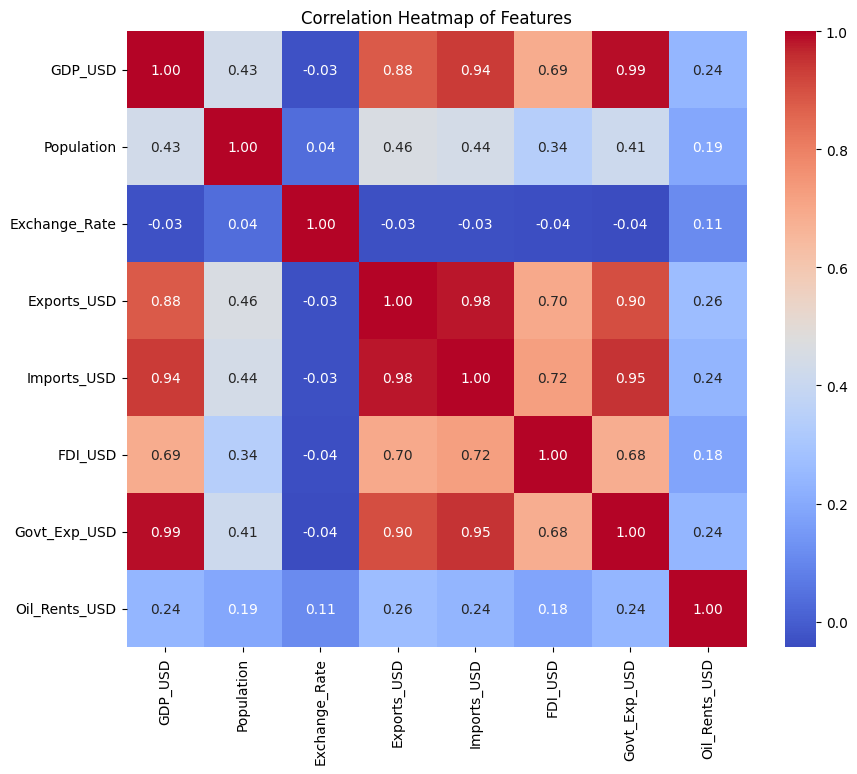

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df.corr(numeric_only=True)

# Display correlation table
print(corr['GDP_USD'].sort_values(ascending=False))

# Heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()
